# 🎙️ YAMNet Cough Detection — Transfer Learning
# YAMNet 咳嗽检测 — 迁移学习

---

## 项目概述 / Project Overview

基于 Google **YAMNet** 音频分类模型，结合 **CoughVid v3**（咳嗽正样本）与 **ESC-50**（非咳嗽负样本）
进行迁移学习，训练一个二分类器：**输入音频 → 输出是否是咳嗽声**。

Transfer learning on Google's **YAMNet** using **CoughVid v3** (cough positives) and **ESC-50** (non-cough negatives)
to build a binary classifier: **audio input → cough or not**.

---

## 数据策略 / Data Strategy

```
正样本 Positive (1000条) ── CoughVid v3 有标签咳嗽音频
                                          ↓
                               合并 2000 条训练数据
                                          ↑
负样本 Negative (1000条) ── ESC-50
    ├── 人声类 280条（喷嚏/呼吸/笑声/哭声/打鼾等）← 难负样本
    └── 其他声音 720条（随机抽取）               ← 背景多样性
```

---

## 技术路线 / Pipeline

```
音频文件 → librosa 加载(16kHz单声道) → YAMNet提取1024维Embedding → 全连接分类器 → 咳嗽/非咳嗽
```

---

## 资源路径 / Resource Paths

| 资源 | 路径 |
|------|------|
| YAMNet 模型 | `/kaggle/input/models/google/yamnet/tensorflow2/yamnet/1` |
| CoughVid v3 | `/kaggle/input/datasets/orvile/coughvid-v3/public_dataset_v3/coughvid_20211012` |
| ESC-50 | `/kaggle/input/datasets/mmoreaux/environmental-sound-classification-50` |
| 输出目录 | `/kaggle/working` |

---
## Step 1 · 安装依赖 / Install Dependencies

In [1]:
!pip install librosa -q
!pip install seaborn -q

---
## Step 2 · 导入库 / Import Libraries

In [2]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import tensorflow as tf
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings('ignore')

# 全局随机种子，保证结果可复现
# Global random seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'✅ TensorFlow : {tf.__version__}')
print(f'✅ GPU 可用   : {tf.config.list_physical_devices("GPU")}')
print(f'✅ librosa    : {librosa.__version__}')

2026-04-10 07:01:28.557762: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775804489.117442      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775804489.216338      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775804490.213918      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775804490.213959      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775804490.213961      24 computation_placer.cc:177] computation placer alr

✅ TensorFlow : 2.19.0
✅ GPU 可用   : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
✅ librosa    : 0.11.0


---
## Step 3 · 全局配置 / Global Configuration

所有关键参数集中管理，需要调整时只改这里。

All parameters managed here — only edit this cell when tuning.

In [3]:
# ── 路径 / Paths ──────────────────────────────────────────────────────────────
YAMNET_PATH   = '/kaggle/input/models/google/yamnet/tensorflow2/yamnet/1'
COUGHVID_PATH = '/kaggle/input/datasets/orvile/coughvid-v3/public_dataset_v3/coughvid_20211012'
# 把原来一行改成两行
ESC50_PATH      = '/kaggle/input/datasets/mmoreaux/environmental-sound-classification-50'
ESC50_AUDIO_DIR = '/kaggle/input/datasets/mmoreaux/environmental-sound-classification-50/audio/audio'
OUTPUT_PATH   = '/kaggle/working'

# ── CoughVid 配置 / CoughVid Config ───────────────────────────────────────────
METADATA_FILE = 'metadata_compiled.csv'
LABEL_COL     = 'status_SSL'
COUGH_LABELS  = ['COVID-19', 'symptomatic', 'healthy']  # 所有有标签的都是真实咳嗽
                                                         # All labeled = real coughs

# ── 样本数量 / Sample Count ───────────────────────────────────────────────────
N_POS         = 1000   # 正样本：咳嗽 / Positive: cough
N_NEG         = 1000   # 负样本：非咳嗽 / Negative: non-cough
N_NEG_OTHER   = 720    # 负样本中非人声数量 / Non-human negatives

# ── ESC-50 人声类别（全部取，约280条）/ ESC-50 human categories (take all ~280) ──
HUMAN_CATEGORIES = [
    'sneezing',    # 喷嚏 — 最像咳嗽，最重要的难负样本
    'breathing',   # 呼吸声
    'laughing',    # 笑声
    'crying_baby', # 哭声
    'snoring',     # 打鼾
    'clapping',    # 鼓掌
    'coughing',    # ESC-50 里也有咳嗽，这里作为负样本增加难度
                   # ESC-50 coughing used as hard negative for diversity
]

# ── 音频配置 / Audio Config ───────────────────────────────────────────────────
SAMPLE_RATE   = 16000  # YAMNet 要求 16kHz / YAMNet requires 16kHz
AUDIO_EXTS    = ['.webm', '.ogg', '.wav', '.mp3']

# ── 数据集划分 / Dataset Split ────────────────────────────────────────────────
TEST_SIZE     = 0.15
VAL_SIZE      = 0.15

# ── 训练配置 / Training Config ────────────────────────────────────────────────
BATCH_SIZE    = 64
EPOCHS        = 50
LR            = 1e-3
PATIENCE      = 8

print('✅ 配置完成 / Configuration ready')
print(f'   正样本数 / Positive : {N_POS} 条（CoughVid）')
print(f'   负样本数 / Negative : {N_NEG} 条（ESC-50：{len(HUMAN_CATEGORIES)}类人声全取 + 其他{N_NEG_OTHER}条）')

✅ 配置完成 / Configuration ready
   正样本数 / Positive : 1000 条（CoughVid）
   负样本数 / Negative : 1000 条（ESC-50：7类人声全取 + 其他720条）


---
## Step 4 · 加载 YAMNet / Load YAMNet

YAMNet 作为**冻结的特征提取器**，权重在训练中不更新，只训练后面的分类层。

YAMNet is a **frozen feature extractor** — weights stay fixed, only the classifier head trains.

In [4]:
print('⏳ 正在加载 YAMNet... / Loading YAMNet...')
yamnet = tf.saved_model.load(YAMNET_PATH)
print('✅ YAMNet 加载成功 / YAMNet loaded')
print('\n📋 模型签名 / Model signature:')
print(yamnet.signatures)

⏳ 正在加载 YAMNet... / Loading YAMNet...


I0000 00:00:1775804527.959100      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775804527.965363      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


✅ YAMNet 加载成功 / YAMNet loaded

📋 模型签名 / Model signature:
_SignatureMap({'serving_default': <ConcreteFunction (*, waveform: TensorSpec(shape=(None,), dtype=tf.float32, name='waveform')) -> Dict[['output_2', TensorSpec(shape=(None, 64), dtype=tf.float32, name='output_2')], ['output_1', TensorSpec(shape=(None, 1024), dtype=tf.float32, name='output_1')], ['output_0', TensorSpec(shape=(None, 521), dtype=tf.float32, name='output_0')]] at 0x7BBB4C792150>})


---
## Step 5 · 定义特征提取函数 / Define Feature Extraction Function

封装音频加载 + YAMNet 推理为一个函数，后续统一调用。

Encapsulate audio loading + YAMNet inference into a reusable function.

In [5]:
def find_audio_path(uuid_val, audio_dir):
    """
    根据 uuid 在目录中查找对应音频文件
    Find audio file by uuid in directory
    """
    for ext in AUDIO_EXTS:
        p = os.path.join(audio_dir, f'{uuid_val}{ext}')
        if os.path.exists(p):
            return p
    return None


def extract_embedding(audio_path, sr=SAMPLE_RATE):
    """
    从音频文件提取 YAMNet 1024 维 Embedding
    Extract 1024-dim YAMNet embedding from audio file

    Args:
        audio_path : str  音频文件路径 / Path to audio file
        sr         : int  目标采样率 / Target sample rate
    Returns:
        np.ndarray (1024,) 或 None
    """
    try:
        # 1. 加载音频，转成 16kHz 单声道
        #    Load audio, convert to 16kHz mono
        wav, _ = librosa.load(audio_path, sr=sr, mono=True)
        wav = wav.astype(np.float32)

        # 2. 跳过静音文件
        #    Skip silent files
        if np.max(np.abs(wav)) < 1e-6:
            return None

        # 3. 归一化到 [-1.0, 1.0]
        #    Normalize to [-1.0, 1.0]
        wav = wav / np.max(np.abs(wav))

        # 4. YAMNet 推理，取 embeddings
        #    YAMNet inference, get embeddings
        _, embeddings, _ = yamnet(wav)

        # 5. 对时间帧取均值 → 固定 1024 维向量
        #    Average over time frames → fixed 1024-dim vector
        return tf.reduce_mean(embeddings, axis=0).numpy()

    except Exception:
        return None  # 静默跳过失败文件 / Silently skip failed files


print('✅ 特征提取函数定义完成 / Feature extraction functions defined')

✅ 特征提取函数定义完成 / Feature extraction functions defined


---
## Step 6 · 准备数据集 / Prepare Dataset

分三部分组装 2000 条训练数据：
1. **正样本**：CoughVid v3 有标签咳嗽音频，随机取 1000 条
2. **负样本（人声）**：ESC-50 人声类别全取，约 280 条
3. **负样本（其他）**：ESC-50 其他类别随机取 720 条

Assembling 2000 training samples in three parts:
1. **Positives**: 1000 labeled coughs from CoughVid v3
2. **Negatives (human)**: All ~280 human-sound clips from ESC-50
3. **Negatives (other)**: 720 random non-human clips from ESC-50

In [6]:
# ══════════════════════════════════════════════════════════════
# 第一部分：CoughVid v3 正样本（咳嗽）
# Part 1: CoughVid v3 positive samples (cough)
# ══════════════════════════════════════════════════════════════

print('📂 加载 CoughVid v3 元数据... / Loading CoughVid v3 metadata...')
df_cv = pd.read_csv(os.path.join(COUGHVID_PATH, METADATA_FILE))

# 只保留有 status_SSL 标签的行（所有有标签的都是真实咳嗽录音）
# Keep only labeled rows (all labeled = real cough recordings)
df_cv = df_cv.dropna(subset=[LABEL_COL]).copy()

# 查找对应音频文件
# Find corresponding audio files
df_cv['audio_path'] = df_cv['uuid'].apply(
    lambda uid: find_audio_path(uid, COUGHVID_PATH)
)
df_cv = df_cv[df_cv['audio_path'].notna()].reset_index(drop=True)

print(f'   可用咳嗽样本 / Available cough samples: {len(df_cv)} 条')

# 随机取 N_POS 条
# Randomly sample N_POS
n_pos = min(N_POS, len(df_cv))
df_pos = df_cv.sample(n=n_pos, random_state=SEED)[['audio_path']].copy()
df_pos['binary_label'] = 1
df_pos['source']       = 'coughvid'

print(f'✅ 正样本 / Positive samples: {len(df_pos)} 条咳嗽')

📂 加载 CoughVid v3 元数据... / Loading CoughVid v3 metadata...
   可用咳嗽样本 / Available cough samples: 8331 条
✅ 正样本 / Positive samples: 1000 条咳嗽


In [7]:
# ══════════════════════════════════════════════════════════════
# 第二部分：ESC-50 负样本（非咳嗽）
# Part 2: ESC-50 negative samples (non-cough)
# ══════════════════════════════════════════════════════════════

print('📂 加载 ESC-50 元数据... / Loading ESC-50 metadata...')
df_esc = pd.read_csv(os.path.join(ESC50_PATH, 'esc50.csv'))

# 构建完整音频路径
# Build full audio path
df_esc['audio_path'] = df_esc['filename'].apply(
    lambda f: os.path.join(ESC50_AUDIO_DIR, f)
)

# 只保留文件存在的行
# Keep only rows with existing files
df_esc = df_esc[df_esc['audio_path'].apply(os.path.exists)].reset_index(drop=True)
print(f'   ESC-50 总有效样本 / Total valid: {len(df_esc)} 条')

# ── 人声类：全部取（约280条，难负样本）──
# Human categories: take all (~280, hard negatives)
df_human = df_esc[df_esc['category'].isin(HUMAN_CATEGORIES)].copy()
print(f'\n   人声类样本 / Human sound samples: {len(df_human)} 条')
print('   各类分布 / Per-category count:')
for cat, cnt in df_human['category'].value_counts().items():
    print(f'      {cat:<20}: {cnt} 条')

# ── 其他类：随机取 N_NEG_OTHER 条（背景声多样性）──
# Other categories: random N_NEG_OTHER (background diversity)
df_other_pool = df_esc[~df_esc['category'].isin(HUMAN_CATEGORIES)]
n_other = min(N_NEG_OTHER, len(df_other_pool))
df_other = df_other_pool.sample(n=n_other, random_state=SEED).copy()
print(f'\n   其他声音样本 / Other sound samples: {len(df_other)} 条')
print(f'   涵盖类别数   / Categories covered  : {df_other["category"].nunique()} 类')

# ── 合并负样本 ──
# Merge negative samples
df_neg = pd.concat([df_human, df_other]).sample(
    frac=1, random_state=SEED
).reset_index(drop=True)[['audio_path', 'category']].copy()
df_neg['binary_label'] = 0
df_neg['source']       = 'esc50'
df_neg = df_neg.drop(columns=['category'])

print(f'\n✅ 负样本 / Negative samples: {len(df_neg)} 条非咳嗽')

📂 加载 ESC-50 元数据... / Loading ESC-50 metadata...
   ESC-50 总有效样本 / Total valid: 2000 条

   人声类样本 / Human sound samples: 280 条
   各类分布 / Per-category count:
      clapping            : 40 条
      laughing            : 40 条
      breathing           : 40 条
      crying_baby         : 40 条
      coughing            : 40 条
      snoring             : 40 条
      sneezing            : 40 条

   其他声音样本 / Other sound samples: 720 条
   涵盖类别数   / Categories covered  : 43 类

✅ 负样本 / Negative samples: 1000 条非咳嗽


✅ 最终数据集 / Final dataset
   总计   / Total    : 2000 条
   正样本 / Positive : 1000 条 (咳嗽 / Cough)
   负样本 / Negative : 1000 条 (非咳嗽 / Non-cough)


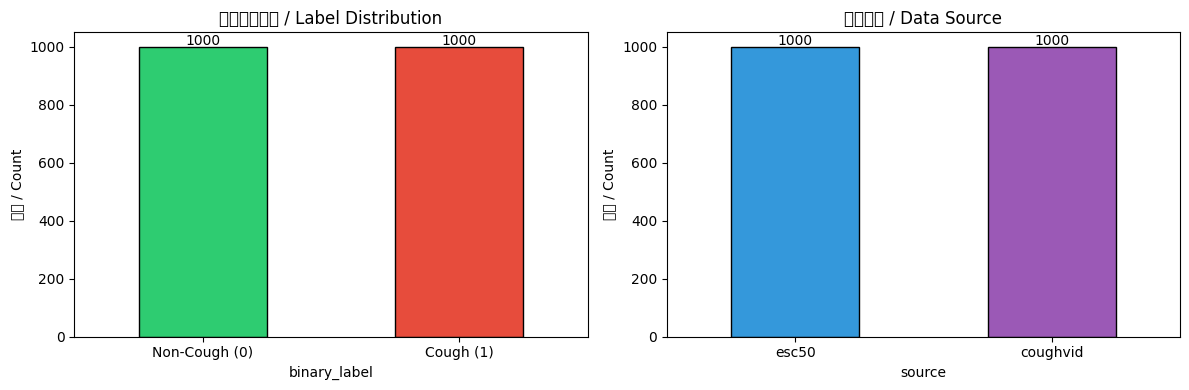

In [8]:
# ══════════════════════════════════════════════════════════════
# 第三部分：合并正负样本，组成最终数据集
# Part 3: Merge positive & negative into final dataset
# ══════════════════════════════════════════════════════════════

df_all = pd.concat([df_pos, df_neg]).sample(
    frac=1, random_state=SEED
).reset_index(drop=True)

print('✅ 最终数据集 / Final dataset')
print(f'   总计   / Total    : {len(df_all)} 条')
print(f'   正样本 / Positive : {(df_all.binary_label==1).sum()} 条 (咳嗽 / Cough)')
print(f'   负样本 / Negative : {(df_all.binary_label==0).sum()} 条 (非咳嗽 / Non-cough)')

# 可视化标签分布
# Visualize label distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 正负样本比例
df_all['binary_label'].value_counts().plot(
    kind='bar', ax=axes[0],
    color=['#2ECC71', '#E74C3C'], edgecolor='black'
)
axes[0].set_xticklabels(['Non-Cough (0)', 'Cough (1)'], rotation=0)
axes[0].set_title('正负样本分布 / Label Distribution')
axes[0].set_ylabel('数量 / Count')
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(int(bar.get_height())), ha='center')

# 数据来源分布
df_all['source'].value_counts().plot(
    kind='bar', ax=axes[1],
    color=['#3498DB', '#9B59B6'], edgecolor='black'
)
axes[1].set_title('数据来源 / Data Source')
axes[1].set_ylabel('数量 / Count')
axes[1].tick_params(axis='x', rotation=0)
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(int(bar.get_height())), ha='center')

plt.tight_layout()
plt.show()

---
## Step 7 · 提取 YAMNet Embedding / Extract YAMNet Embeddings

遍历所有 2000 条音频，提取 1024 维特征向量。
YAMNet 内部将音频切成 0.96 秒滑动窗口，我们对所有帧取均值得到固定长度向量。

Extract 1024-dim feature vectors from all 2000 audio clips.
YAMNet slices audio into 0.96s windows; we average all frames into one fixed vector.

> ⏱️ 2000 条在 GPU T4 上约 **3–5 分钟** / ~3–5 min on GPU T4

In [9]:
X_list, y_list, skip_count = [], [], 0

print(f'⏳ 开始提取 {len(df_all)} 条音频的 Embedding...')
print(f'⏳ Extracting embeddings for {len(df_all)} clips...\n')

for _, row in tqdm(df_all.iterrows(), total=len(df_all), desc='Embedding'):
    emb = extract_embedding(row['audio_path'])
    if emb is None:
        skip_count += 1
        continue
    X_list.append(emb)
    y_list.append(row['binary_label'])

X = np.array(X_list, dtype=np.float32)  # (N, 1024)
y = np.array(y_list, dtype=np.float32)  # (N,)

print(f'\n✅ 提取完成 / Extraction done')
print(f'   成功 / Success  : {len(X)}')
print(f'   跳过 / Skipped  : {skip_count}')
print(f'   维度 / X shape  : {X.shape}')
print(f'   咳嗽比例 / Cough%: {y.mean()*100:.1f}%')

# 提取完成后立即保存，下次直接加载跳过此步骤
# Save immediately after extraction — load next time to skip this step
np.savez(os.path.join(OUTPUT_PATH, 'embeddings.npz'), X=X, y=y)
print(f'\n💾 Embedding 已保存 / Saved to: {OUTPUT_PATH}/embeddings.npz')
print('   下次可直接加载，跳过提取步骤 / Next time load directly to skip extraction')

⏳ 开始提取 2000 条音频的 Embedding...
⏳ Extracting embeddings for 2000 clips...



Embedding: 100%|██████████| 2000/2000 [03:20<00:00,  9.98it/s]


✅ 提取完成 / Extraction done
   成功 / Success  : 2000
   跳过 / Skipped  : 0
   维度 / X shape  : (2000, 1024)
   咳嗽比例 / Cough%: 50.0%

💾 Embedding 已保存 / Saved to: /kaggle/working/embeddings.npz
   下次可直接加载，跳过提取步骤 / Next time load directly to skip extraction


---
## Step 8 · 划分数据集 / Split Dataset

按 **训练 70% / 验证 15% / 测试 15%** 划分，`stratify` 保持各集合正负比例一致。

Split **Train 70% / Val 15% / Test 15%** with stratified sampling.

In [10]:
# 第一次切分：训练+验证 vs 测试
# First split: train+val vs test
X_tv, X_test, y_tv, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y
)

# 第二次切分：训练 vs 验证
# Second split: train vs val
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=VAL_SIZE, random_state=SEED, stratify=y_tv
)

total = len(X)
print('✅ 数据集划分完成 / Dataset split done')
print(f'   训练集 Train : {len(X_train):>5} ({len(X_train)/total*100:.1f}%)')
print(f'   验证集 Val   : {len(X_val):>5} ({len(X_val)/total*100:.1f}%)')
print(f'   测试集 Test  : {len(X_test):>5} ({len(X_test)/total*100:.1f}%)')

✅ 数据集划分完成 / Dataset split done
   训练集 Train :  1445 (72.2%)
   验证集 Val   :   255 (12.8%)
   测试集 Test  :   300 (15.0%)


---
## Step 9 · 构建分类器 / Build Classifier

在 YAMNet 的 1024 维 Embedding 后接轻量全连接网络：

```
Input(1024) → Dense(256)+BN+ReLU+Dropout(0.4)
            → Dense(64)+BN+ReLU+Dropout(0.3)
            → Dense(1, sigmoid) → 咳嗽概率
```

In [11]:
def build_model(input_dim=1024):
    """
    构建咳嗽二分类器
    Build binary cough classifier
    输入 Input : (1024,) YAMNet embedding
    输出 Output: 咳嗽概率 [0,1] / Cough probability
    """
    inputs = tf.keras.Input(shape=(input_dim,), name='yamnet_embedding')

    # 第一个全连接块 / First dense block
    x = tf.keras.layers.Dense(256, name='dense_1')(inputs)
    x = tf.keras.layers.BatchNormalization(name='bn_1')(x)
    x = tf.keras.layers.Activation('relu', name='relu_1')(x)
    x = tf.keras.layers.Dropout(0.4, name='drop_1')(x)

    # 第二个全连接块 / Second dense block
    x = tf.keras.layers.Dense(64, name='dense_2')(x)
    x = tf.keras.layers.BatchNormalization(name='bn_2')(x)
    x = tf.keras.layers.Activation('relu', name='relu_2')(x)
    x = tf.keras.layers.Dropout(0.3, name='drop_2')(x)

    # 输出层：sigmoid 二分类 / Output: sigmoid binary
    outputs = tf.keras.layers.Dense(1, activation='sigmoid', name='cough_prob')(x)

    return tf.keras.Model(inputs, outputs, name='CoughClassifier')


model = build_model()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

model.summary()

Model: "CoughClassifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ yamnet_embedding (InputLayer)   │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_1 (Activation)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_2 (Activation)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cough_prob (Dense)              │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 280,193 (1.07 MB)

 Trainable params: 279,553 (1.07 MB)

 Non-trainable params: 640 (2.50 KB)

---
## Step 10 · 训练 / Train

三重回调保障训练质量：

| 回调 | 触发条件 | 作用 |
|------|---------|------|
| `EarlyStopping` | val_auc 连续 8 轮不提升 | 停止训练，恢复最佳权重 |
| `ReduceLROnPlateau` | val_auc 连续 3 轮不提升 | 学习率 × 0.5 |
| `ModelCheckpoint` | 每轮 val_auc 更高时 | 保存最佳模型 |

In [12]:
best_model_path = os.path.join(OUTPUT_PATH, 'best_cough_classifier.keras')

callbacks = [
    # 早停 / Early stopping
    tf.keras.callbacks.EarlyStopping(
        monitor='val_auc', patience=PATIENCE,
        restore_best_weights=True, mode='max', verbose=1
    ),
    # 学习率衰减 / LR decay
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_auc', factor=0.5, patience=3,
        min_lr=1e-6, mode='max', verbose=1
    ),
    # 保存最佳模型 / Save best model
    tf.keras.callbacks.ModelCheckpoint(
        filepath=best_model_path,
        monitor='val_auc', save_best_only=True,
        mode='max', verbose=1
    ),
]

print('🚀 开始训练 / Start training...\n')
history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)
print('\n✅ 训练完成 / Training complete')

🚀 开始训练 / Start training...

Epoch 1/50


I0000 00:00:1775804782.181380      81 service.cc:152] XLA service 0x7bbb24013120 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775804782.181436      81 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775804782.181444      81 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5


20/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7718 - auc: 0.8668 - loss: 0.4735 - precision: 0.8351 - recall: 0.6904 

I0000 00:00:1775804784.741268      81 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.7806 - auc: 0.8737 - loss: 0.4599 - precision: 0.8375 - recall: 0.7073
Epoch 1: val_auc improved from -inf to 0.98259, saving model to /kaggle/working/best_cough_classifier.keras
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 179ms/step - accuracy: 0.7831 - auc: 0.8757 - loss: 0.4560 - precision: 0.8382 - recall: 0.7121 - val_accuracy: 0.8392 - val_auc: 0.9826 - val_loss: 0.3338 - val_precision: 0.7560 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/50
20/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9078 - auc: 0.9661 - loss: 0.2409 - precision: 0.9129 - recall: 0.9073 
Epoch 2: val_auc improved from 0.98259 to 0.98631, saving model to /kaggle/working/best_cough_classifier.keras
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9083 - auc: 0.9658 - loss: 0.2406 - precision: 0.9112 - recall: 0.9095 - val_accuracy: 0.9608 - val_auc: 0.9863 - val_loss: 0.1997 - val_precision: 0.9333 - val_recall: 0.9921 - learning_rate: 0.0010
Epoch 3/50


---
## Step 11 · 可视化训练过程 / Visualize Training History

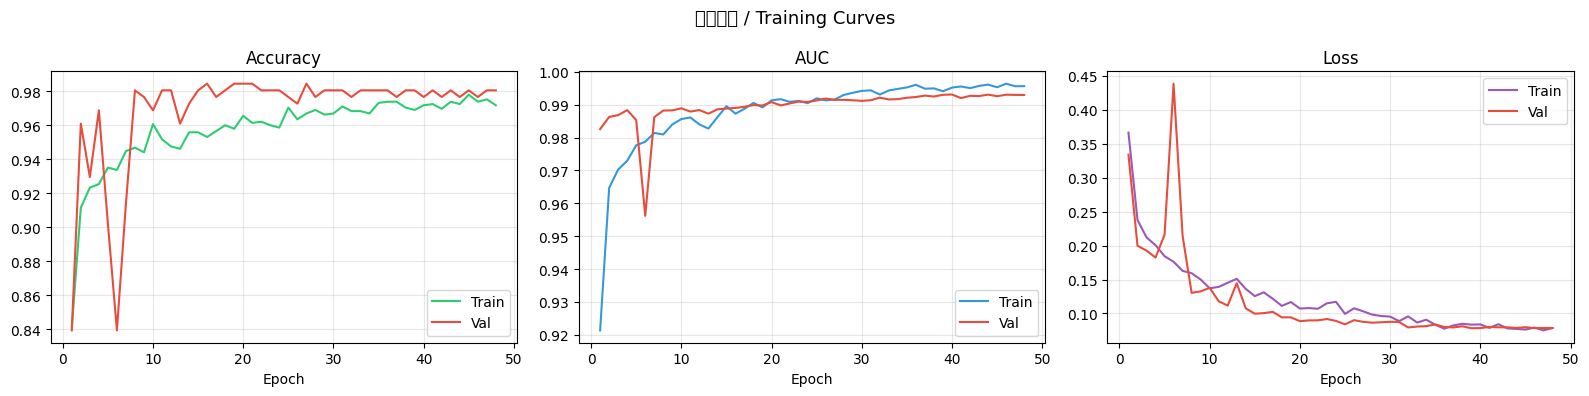

✅ 训练曲线已保存 / Curves saved


In [13]:
h = history.history
epochs_ran = range(1, len(h['loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('训练曲线 / Training Curves', fontsize=13)

# 准确率 / Accuracy
axes[0].plot(epochs_ran, h['accuracy'],     label='Train', color='#2ECC71')
axes[0].plot(epochs_ran, h['val_accuracy'], label='Val',   color='#E74C3C')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)

# AUC
axes[1].plot(epochs_ran, h['auc'],     label='Train', color='#3498DB')
axes[1].plot(epochs_ran, h['val_auc'], label='Val',   color='#E74C3C')
axes[1].set_title('AUC')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(alpha=0.3)

# 损失 / Loss
axes[2].plot(epochs_ran, h['loss'],     label='Train', color='#9B59B6')
axes[2].plot(epochs_ran, h['val_loss'], label='Val',   color='#E74C3C')
axes[2].set_title('Loss')
axes[2].set_xlabel('Epoch')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ 训练曲线已保存 / Curves saved')

---
## Step 12 · 测试集评估 / Test Set Evaluation

在模型从未见过的测试集上评估最终性能。

Final evaluation on the held-out test set.

In [14]:
# 数值指标 / Numeric metrics
results = model.evaluate(X_test, y_test, verbose=0)
metric_names = ['Loss', 'Accuracy', 'AUC', 'Precision', 'Recall']

print('📊 测试集结果 / Test Set Results')
print('=' * 40)
for name, val in zip(metric_names, results):
    print(f'   {name:<12}: {val:.4f}')

precision = results[3]
recall    = results[4]
f1 = 2 * precision * recall / (precision + recall + 1e-8)
print(f'   {"F1":<12}: {f1:.4f}')

📊 测试集结果 / Test Set Results
   Loss        : 0.0868
   Accuracy    : 0.9733
   AUC         : 0.9958
   Precision   : 0.9671
   Recall      : 0.9800
   F1          : 0.9735



📋 分类报告 / Classification Report
               precision    recall  f1-score   support

Non-Cough (0)       0.98      0.97      0.97       150
    Cough (1)       0.97      0.98      0.97       150

     accuracy                           0.97       300
    macro avg       0.97      0.97      0.97       300
 weighted avg       0.97      0.97      0.97       300



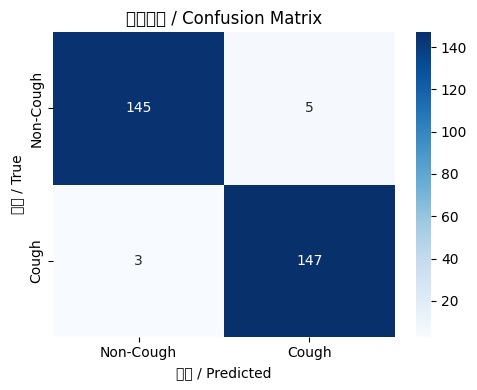

In [15]:
# 分类报告 + 混淆矩阵 / Classification report + confusion matrix
y_prob = model.predict(X_test, verbose=0).flatten()
y_pred = (y_prob > 0.5).astype(int)

print('\n📋 分类报告 / Classification Report')
print('=' * 50)
print(classification_report(
    y_test, y_pred,
    target_names=['Non-Cough (0)', 'Cough (1)']
))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', ax=ax,
    xticklabels=['Non-Cough', 'Cough'],
    yticklabels=['Non-Cough', 'Cough']
)
ax.set_title('混淆矩阵 / Confusion Matrix')
ax.set_xlabel('预测 / Predicted')
ax.set_ylabel('真实 / True')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## Step 13 · 保存模型 / Save Model

In [16]:
# 保存最终模型（Keras 格式）
# Save final model in Keras format
final_keras = os.path.join(OUTPUT_PATH, 'cough_classifier_final.keras')
model.save(final_keras)
print(f'✅ 模型已保存 / Model saved: {final_keras}')

# 列出所有输出文件
# List all output files
print('\n📁 输出文件 / Output files:')
for f in sorted(os.listdir(OUTPUT_PATH)):
    if not os.path.isdir(os.path.join(OUTPUT_PATH, f)):
        size = os.path.getsize(os.path.join(OUTPUT_PATH, f))
        print(f'   {f:<45} {size/1024:.1f} KB')

✅ 模型已保存 / Model saved: /kaggle/working/cough_classifier_final.keras

📁 输出文件 / Output files:
   __notebook__.ipynb                            492.2 KB
   best_cough_classifier.keras                   3327.7 KB
   confusion_matrix.png                          28.9 KB
   cough_classifier_final.keras                  3327.7 KB
   embeddings.npz                                8008.3 KB
   training_curves.png                           137.1 KB


---
## Step 14 · 推理示例 / Inference Demo

端到端推理函数：输入任意音频路径 → 输出咳嗽概率和判定结果。

End-to-end inference: input any audio path → cough probability + decision.

In [17]:
def detect_cough(audio_path, threshold=0.5):
    """
    端到端咳嗽检测 / End-to-end cough detection

    Args:
        audio_path : str   音频文件路径 / Path to audio
        threshold  : float 判定阈值 / Decision threshold (default 0.5)
    Returns:
        dict: probability, is_cough, label, confidence
    """
    emb = extract_embedding(audio_path)
    if emb is None:
        print('❌ 音频处理失败 / Audio processing failed')
        return None

    prob     = float(model.predict(emb[np.newaxis, :], verbose=0)[0][0])
    is_cough = prob > threshold

    result = {
        'probability' : round(prob, 4),
        'is_cough'    : is_cough,
        'label'       : '🔴 咳嗽 COUGH'      if is_cough else '🟢 非咳嗽 NOT COUGH',
        'confidence'  : f'{max(prob, 1-prob)*100:.1f}%'
    }

    print(f'文件       / File       : {os.path.basename(audio_path)}')
    print(f'咳嗽概率   / Probability: {prob:.4f}')
    print(f'判定结果   / Result     : {result["label"]}')
    print(f'置信度     / Confidence : {result["confidence"]}')
    return result


# 用测试集随机一条验证
# Quick demo with a random test sample
print('🔍 推理示例 / Inference Demo')
print('=' * 45)
demo_idx  = 0
demo_prob = float(model.predict(X_test[demo_idx:demo_idx+1], verbose=0)[0][0])
demo_pred = '🔴 Cough' if demo_prob > 0.5 else '🟢 Non-Cough'
demo_true = '🔴 Cough' if y_test[demo_idx] == 1 else '🟢 Non-Cough'
print(f'真实标签 / True  : {demo_true}')
print(f'预测结果 / Pred  : {demo_pred} (prob={demo_prob:.4f})')
print(f'\n📌 使用方法 / Usage:')
print("   detect_cough('/path/to/audio.wav')")

🔍 推理示例 / Inference Demo
真实标签 / True  : 🟢 Non-Cough
预测结果 / Pred  : 🟢 Non-Cough (prob=0.0029)

📌 使用方法 / Usage:
   detect_cough('/path/to/audio.wav')


---
## 总结 / Summary

| 步骤 | 内容 |
|------|------|
| 1–2 | 安装依赖，导入库 |
| 3   | 全局配置 |
| 4   | 加载 YAMNet |
| 5   | 定义特征提取函数 |
| 6   | 组装数据集（CoughVid正样本 + ESC-50负样本）|
| 7   | 提取 1024 维 Embedding，自动保存 |
| 8   | 划分训练/验证/测试集 70/15/15 |
| 9   | 构建分类器 |
| 10  | 训练（早停 + LR衰减 + 最佳模型保存）|
| 11  | 可视化训练曲线 |
| 12  | 测试集评估 + 混淆矩阵 |
| 13  | 保存模型 |
| 14  | 推理示例 |

---

**🔜 下一步 / Next Step**

结合 **SpeechBrain** 声纹识别，实现：
```
音频 → YAMNet咳嗽检测 → 是咳嗽 → SpeechBrain声纹识别 → 输出是谁在咳嗽
```